In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlite3
## opens sqlite database

conn = sqlite3.connect("./data/game.db")

def statement_to_df(s: str):
    cursor = conn.cursor()
    cursor.execute(s)
    conn.commit()
    cols = [description[0] for description in cursor.description]
    list = cursor.fetchall()
    df = pd.DataFrame(list, columns=cols)
    return df

def get_tables():
    cursor = conn.cursor()
    cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
    tables = cursor.fetchall()
    return [table[0] for table in tables]

    

def plot_statement(s: str):
    df = statement_to_df(s)
    ## now plot
    plt.plot(df)
    plt.show()

In [26]:
def ships_over_frame(max_frames = 999999999):
  result = statement_to_df(f"""
    with combined as (select * from (select frame, 1 as val, owner from ships_created
    union all 
    select frame, -1 as val, owner from ships_destroyed)
    order by frame
  ),
  grouped as (select x, sum(y) over (order by x) as y from (select frame as x, sum(val) as y from combined group by frame))
  select * from grouped where x <= {max_frames} order by x;
  """)
  return result

def ships_grouped_over_frame(max_frames = 999999999):
  result = statement_to_df(f"""
    with combined as (select * from (select frame, 1 as val, owner from ships_created
    union all 
    select frame, -1 as val, owner from ships_destroyed)
    order by frame
  ),
  partitioned as (select owner, x, sum(y) over (partition by owner order by x) as y 
  from (select owner, frame as x, sum(val) as y from combined group by frame, owner)
  )

  select * from partitioned where x <= {max_frames} order by owner, x;
                           
""")
  return result




In [27]:
get_tables()

['ships_destroyed',
 'ships_created',
 'players',
 'servers',
 'server_ticks',
 'pings',
 'player_counts']

In [ ]:
def plot_all(max_frames = 999999999):
    fig, axes = plt.subplots(4, 1, figsize=(16,12), dpi=160, sharex = True)
    ticks = statement_to_df(f"select tick as x, micros_elapsed / 1000.0 as y from server_ticks where tick <= {max_frames}")
    axes[0].plot(ticks["x"], ticks["y"], )
    axes[0].set_title("Server time to calculate tick")
    axes[0].set_ylabel("Server Tick (ms)")

    pings = statement_to_df(f"select tick as x, micros / 1000.0 as y from pings where tick <= {max_frames}")
    # ping_moving_avg = pings["y"].rolling(window=5).mean()
    axes[1].plot(pings["x"], pings["y"])
    axes[1].set_title("Client ping over time")
    axes[1].set_ylabel("Ping (ms)")

    ships = ships_over_frame(max_frames)
    axes[2].plot(ships["x"], ships["y"], label="Total Ships")
    axes[2].set_title("Total ships over time")
    axes[2].set_ylabel("Ships")

    for name, group in ships_grouped_over_frame(max_frames).groupby(["owner"]):
        #extend line to the end
        if len(group["x"]) > 1:
            axes[3].plot(group["x"], group["y"], label=name)
        else:
            axes[3].scatter(group["x"], group["y"], label=name)

    total_seconds = ticks["x"].max()*1/60
    axes[3].set_title("Ships per player over time")
    axes[3].set_xlabel(f"Frame ({total_seconds.round()} seconds)")
    #axes[3].legend()
# player_counts = statement_to_df("select tick as x, count as y from player_counts")


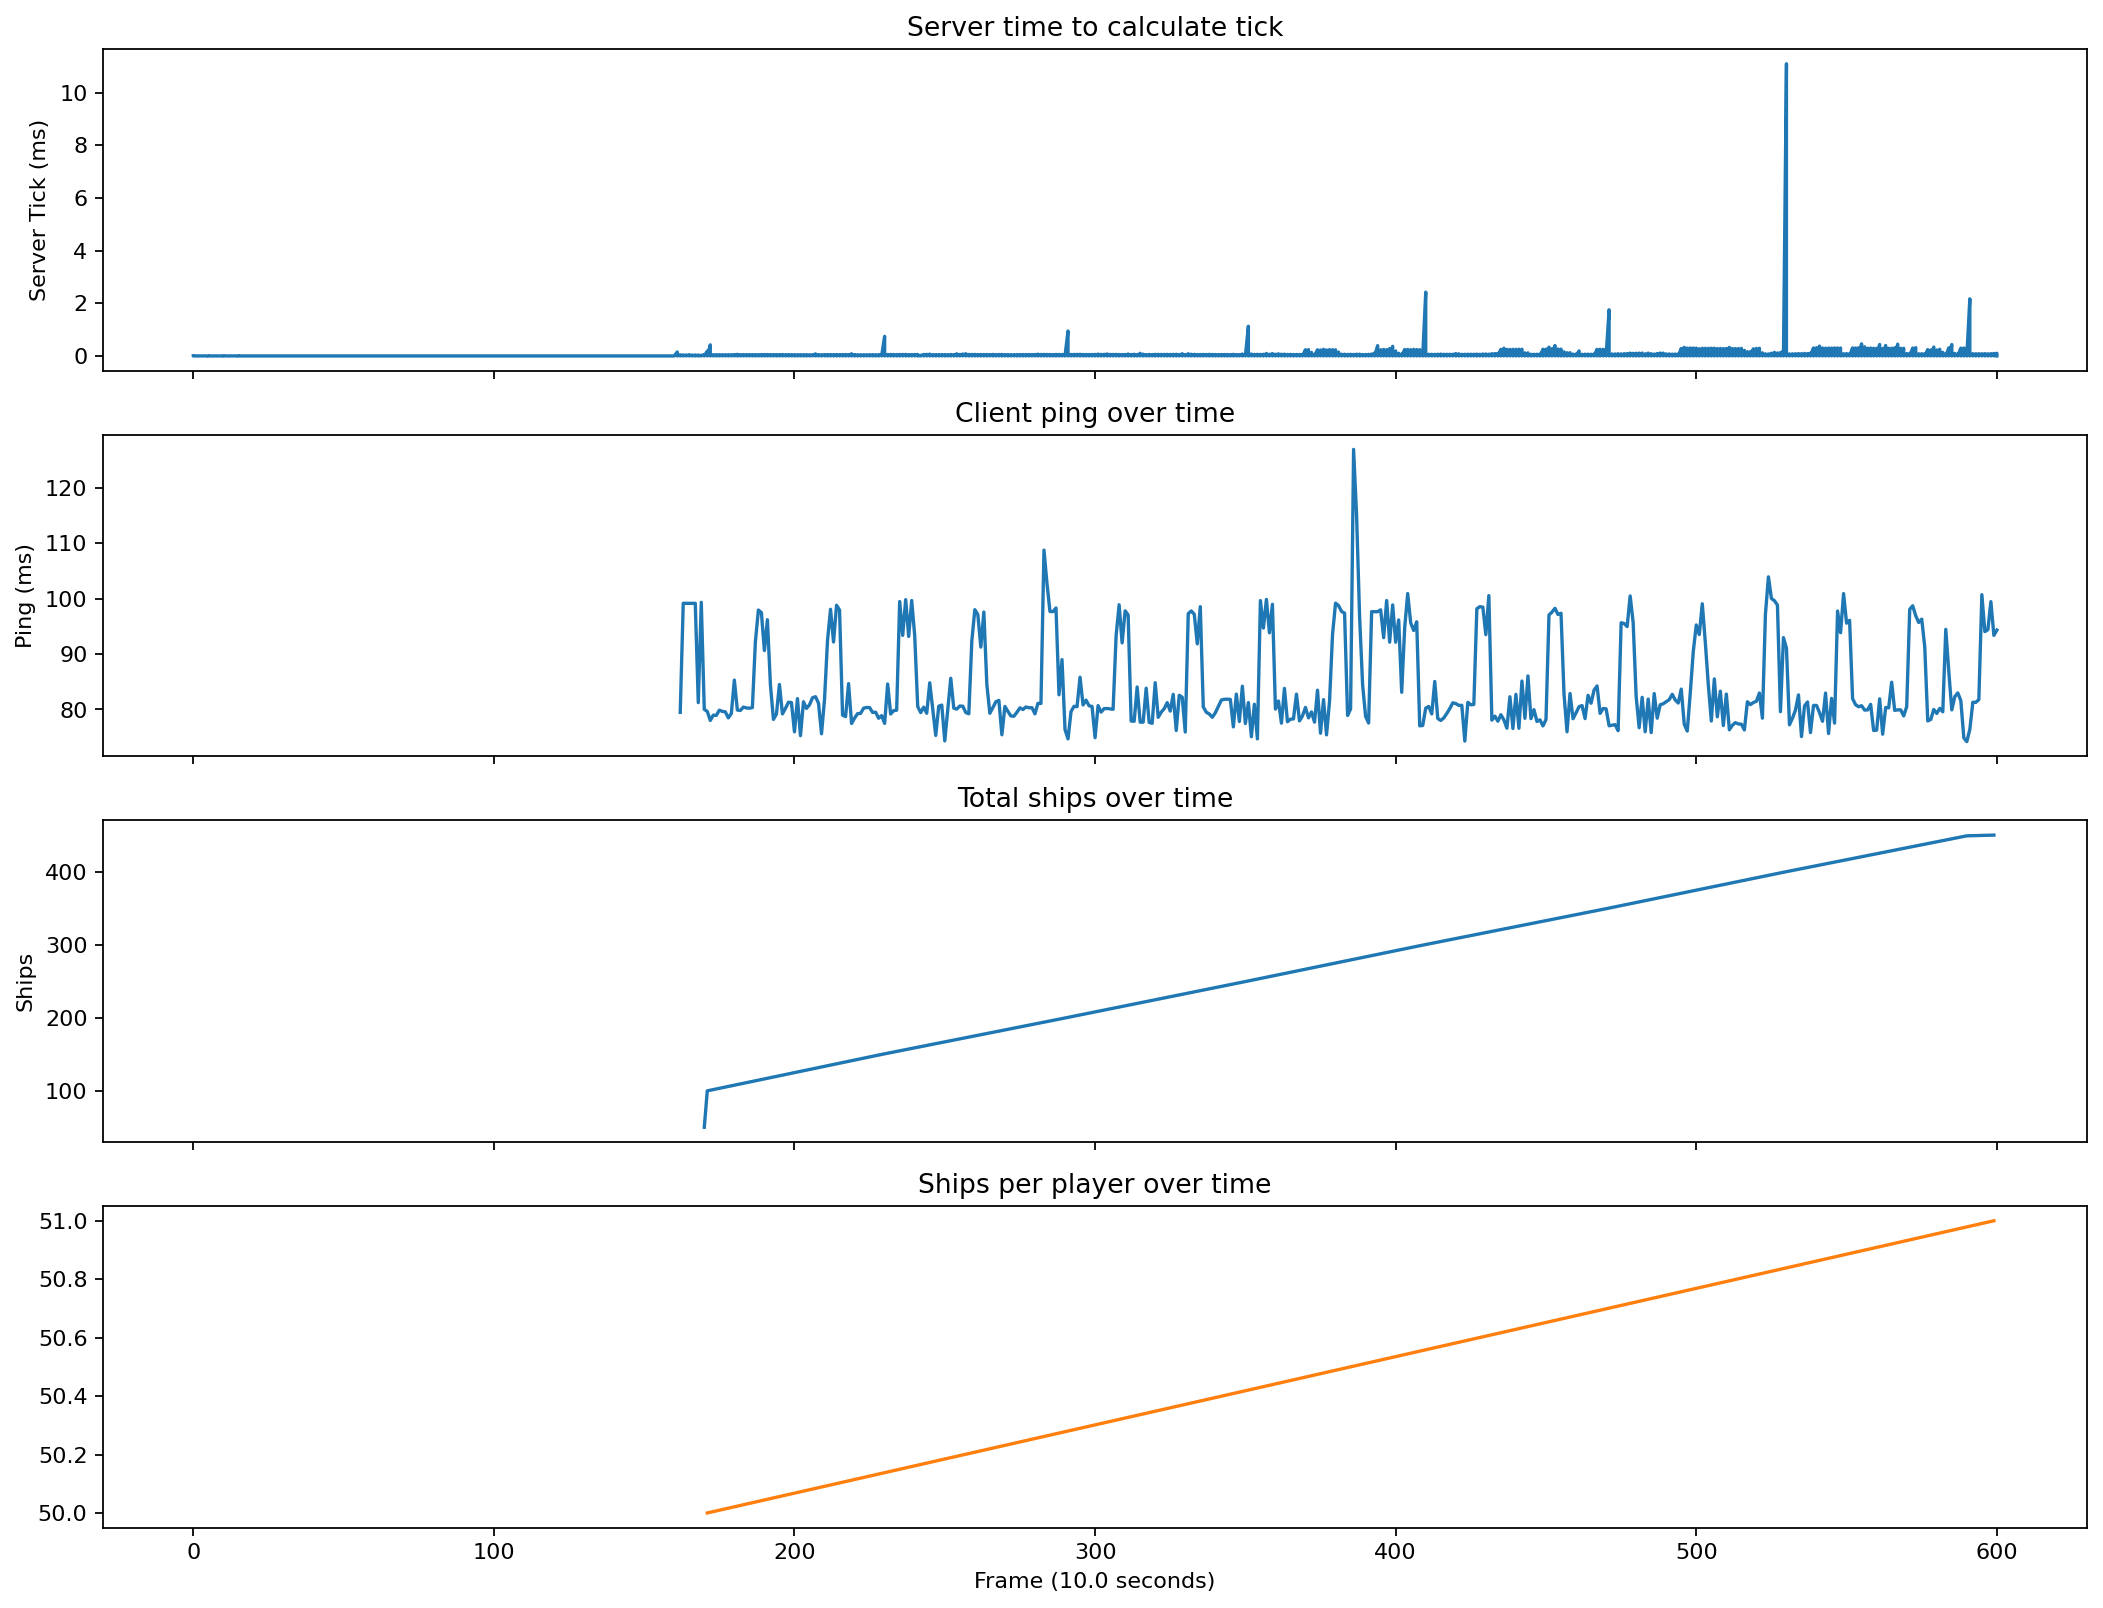

In [51]:
plot_all(600)

(array([2.000e+00, 3.000e+00, 9.000e+01, 5.320e+02, 1.552e+03, 1.686e+03,
        2.070e+03, 2.283e+03, 1.124e+03, 3.780e+02, 8.700e+01, 1.070e+02,
        2.850e+02, 5.980e+02, 1.131e+03, 1.042e+03, 6.890e+02, 5.190e+02,
        2.040e+02, 8.100e+01, 4.200e+01, 8.700e+01, 9.600e+01, 7.600e+01,
        6.400e+01, 3.900e+01, 2.500e+01, 1.600e+01, 1.000e+01, 2.100e+01,
        2.100e+01, 2.300e+01, 2.000e+01, 8.000e+00, 1.500e+01, 1.600e+01,
        1.100e+01, 1.400e+01, 6.000e+00, 1.100e+01, 1.000e+01, 2.000e+00,
        4.000e+00, 2.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 1.000e+00]),
 array([ 68.544  ,  70.33772,  72.13144,  73.92516,  75.71888,  77.5126 ,
         79.30632,  81.10004,  82.89376,  84.68748,  86.4812 ,  88.27492,
         90.06864,  91.86236,  93.65608,  95.4498 ,  97.24352,  99.03724,
        100.83096, 102.62468, 104.4184 , 106.21212, 108.00584, 109.79956,
        111.59328, 113.387  , 115.18072, 116.97444, 118.76816, 120.56188,
      

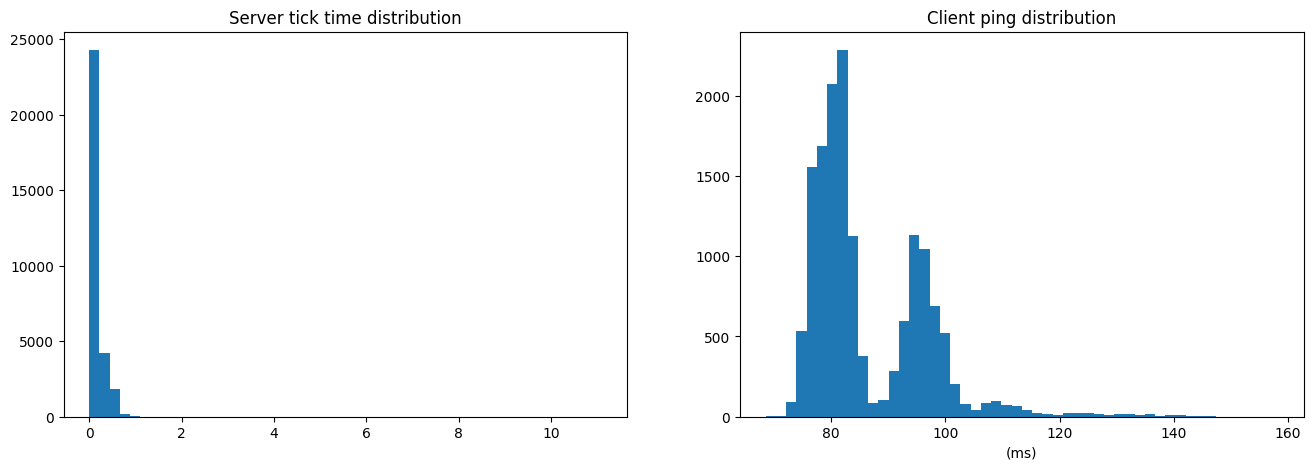

In [30]:
fig, axes = plt.subplots(1,2, figsize=(16, 5))
axes[0].set_title("Server tick time distribution")
axes[0].hist(ticks["y"], bins=50)
axes[1].set_xlabel("(ms)")
axes[1].set_title("Client ping distribution")
axes[1].set_xlabel("(ms)")
axes[1].hist(pings["y"], bins=50)